## 2 NDArray

### 2.1 向量与矩阵计算

给定

$$
a=[2,-1,3]^T,\quad b=[1,4,-2]^T,
$$

$$
A=\begin{bmatrix}1&0&2\\-1&3&1\end{bmatrix},\quad
B=\begin{bmatrix}2&1\\0&-1\\3&2\end{bmatrix}.
$$

需要计算 $a\cdot b$、$A\times B$ 以及 $a$ 的 Frobenius 范数。对于向量而言，Frobenius 范数与 Euclidean 范数一致。

In [1]:
import numpy as np

# 定义向量和矩阵
a = np.array([2, -1, 3])
b = np.array([1, 4, -2])
A = np.array([[1, 0, 2],
              [-1, 3, 1]])
B = np.array([[2, 1],
              [0, -1],
              [3, 2]])

# 1. 点积
ab_dot = np.dot(a, b)

# 2. 矩阵乘法
AB = A @ B

# 3. Frobenius/Euclidean 范数
a_norm = np.linalg.norm(a, ord='fro' if a.ndim == 2 else None)

print('a · b =', ab_dot)
print('A × B =')
print(AB)
print('||a||_F =', a_norm)


a · b = -8
A × B =
[[ 8  5]
 [ 1 -2]]
||a||_F = 3.7416573867739413


解析结果为

$$
a\cdot b=2\times1+(-1)\times4+3\times(-2)=-8,
$$

$$
A B=\begin{bmatrix}8&5\\1&-2\end{bmatrix},
$$

$$
\lVert a\rVert_F=\sqrt{2^2+(-1)^2+3^2}=\sqrt{14}\approx3.7417.
$$

### 2.2 使用 NumPy 构造张量并计算

本题要求使用 NumPy 完成类似深度学习框架中张量操作的计算：构造 $3\times4$ 的矩阵 $X$，构造 $4\times2$ 且元素全为 1 的矩阵 $Y$，计算 $Z=X\times Y$，输出 $Z$ 的形状并计算 $Z$ 的 Frobenius 范数。

In [2]:
# 构造 3×4 矩阵 X
X = np.arange(12).reshape(3, 4)

# 构造 4×2 且元素为 1 的矩阵 Y
Y = np.ones((4, 2))

# 矩阵乘法
Z = X @ Y

print('X =')
print(X)
print('\nY =')
print(Y)
print('\nZ = X @ Y =')
print(Z)
print('\nZ.shape =', Z.shape)
print('||Z||_F =', np.linalg.norm(Z, ord='fro'))


X =
[[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]

Y =
[[1. 1.]
 [1. 1.]
 [1. 1.]
 [1. 1.]]

Z = X @ Y =
[[ 6.  6.]
 [22. 22.]
 [38. 38.]]

Z.shape = (3, 2)
||Z||_F = 62.67375846396959


因为 $X\in\mathbb{R}^{3\times4}$ 且 $Y\in\mathbb{R}^{4\times2}$，所以

$$
Z=XY\in\mathbb{R}^{3\times2}.
$$

以上代码将直接输出 $Z$ 的形状和 Frobenius 范数。

## 3 概率与随机模拟

### 3.1 条件概率与贝叶斯公式

根据 PDF 页面中可识别的数值，本题可还原为一个典型的医学检测或二分类检测的条件概率问题。这里采用如下设定：某事件或疾病的先验概率为 $0.1\%$，若事件真实发生，检测为阳性的概率为 $99\%$；若事件未发生，检测误报为阳性的概率为 $2\%$。要求计算检测为阳性时，事件真实发生的后验概率。

令 $D$ 表示真实发生，$+$ 表示检测阳性，则

$$
P(D)=0.001,\quad P(+\mid D)=0.99,\quad P(+\mid D^c)=0.02.
$$

由贝叶斯公式可得

$$
P(D\mid +)=\frac{P(+\mid D)P(D)}{P(+\mid D)P(D)+P(+\mid D^c)P(D^c)}.
$$

In [3]:
p_D = 0.001
p_pos_given_D = 0.99
p_pos_given_not_D = 0.02

p_D_given_pos = (p_pos_given_D * p_D) / (p_pos_given_D * p_D + p_pos_given_not_D * (1 - p_D))
print('P(D | +) =', p_D_given_pos)
print('百分比 = {:.2f}%'.format(100 * p_D_given_pos))


P(D | +) = 0.047210300429184546
百分比 = 4.72%


因此，在低先验概率情形下，即使检测灵敏度达到 $99\%$，由于误报率和基准率的影响，阳性后的真实发生概率仍约为 **4.72%**。若教师原题中三个百分比对应的含义不同，只需在上述代码中调整三个概率定义即可得到对应答案。

### 3.2 使用 Python 进行 Monte Carlo 随机模拟

根据 PDF 中可识别信息，本题要求使用 Python 生成 $n=10000$ 个服从 $U(0,1)$ 的随机数，并设置重复次数 $m=1000$。这里通过 Monte Carlo 模拟验证均匀分布样本均值的稳定性：每次生成 $n$ 个 $U(0,1)$ 样本，计算样本均值，重复 $m$ 次。理论上，$U(0,1)$ 的期望为 $0.5$，方差为 $1/12$，样本均值的标准差为 $\sqrt{1/(12n)}$。

重复次数 m = 1000
每次样本量 n = 10000
样本均值的平均值 = 0.49992002501832034
样本均值的标准差 = 0.002825050596035652
理论期望 E[U(0,1)] = 0.5
理论样本均值标准差 = 0.002886751345948129


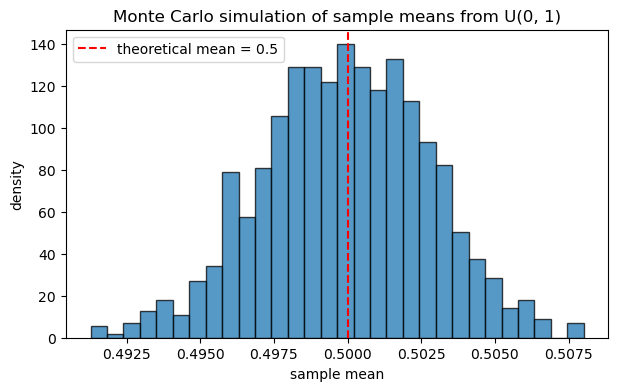

In [4]:
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)
n = 10000
m = 1000

# 每一行是一次实验，共 m 次；每次实验包含 n 个 U(0,1) 随机数
samples = rng.uniform(0, 1, size=(m, n))
sample_means = samples.mean(axis=1)

print('重复次数 m =', m)
print('每次样本量 n =', n)
print('样本均值的平均值 =', sample_means.mean())
print('样本均值的标准差 =', sample_means.std(ddof=1))
print('理论期望 E[U(0,1)] =', 0.5)
print('理论样本均值标准差 =', np.sqrt(1/(12*n)))

plt.figure(figsize=(7, 4))
plt.hist(sample_means, bins=30, density=True, alpha=0.75, edgecolor='black')
plt.axvline(0.5, color='red', linestyle='--', label='theoretical mean = 0.5')
plt.title('Monte Carlo simulation of sample means from U(0, 1)')
plt.xlabel('sample mean')
plt.ylabel('density')
plt.legend()
plt.show()


从模拟结果可以看到，样本均值高度集中在 $0.5$ 附近，且重复实验得到的样本均值标准差接近理论值 $\sqrt{1/(12n)}$。这说明随着样本量 $n$ 增大，样本均值会稳定收敛到总体期望。

## 4 梯度计算与自动微分

### 4.1 手工求偏导

给定

$$
z=(w_1x_1+w_2x_2-y)^2,\quad x_1=2,x_2=1,y=3.
$$

令

$$
e=w_1x_1+w_2x_2-y,
$$

则 $z=e^2$。由链式法则可得

$$
\frac{\partial z}{\partial w_1}=2e x_1,
\quad
\frac{\partial z}{\partial w_2}=2e x_2.
$$

In [5]:
x1, x2, y = 2, 1, 3
w1, w2 = 0.5, 1

e = w1 * x1 + w2 * x2 - y
dz_dw1 = 2 * e * x1
dz_dw2 = 2 * e * x2
z = e ** 2

print('e =', e)
print('z =', z)
print('∂z/∂w1 =', dz_dw1)
print('∂z/∂w2 =', dz_dw2)


e = -1.0
z = 1.0
∂z/∂w1 = -4.0
∂z/∂w2 = -2.0


当 $w_1=0.5,w_2=1$ 时，

$$
e=0.5\times2+1\times1-3=-1,
$$

因此

$$
\frac{\partial z}{\partial w_1}=2(-1)\times2=-4,
\quad
\frac{\partial z}{\partial w_2}=2(-1)\times1=-2.
$$

### 4.2 使用 `torch.autograd` 计算梯度

计算关系为

$$
a=xw_1,\quad b=a+w_2,\quad L=b^2.
$$

给定 $x=2,w_1=1.5,w_2=0.5$，则 $a=3$，$b=3.5$，$L=12.25$。由链式法则可得

$$
\frac{\partial L}{\partial w_1}=2b\cdot x=14,
\quad
\frac{\partial L}{\partial w_2}=2b=7.
$$

In [6]:
# 如果当前环境安装了 PyTorch，则使用 torch.autograd；否则输出解析结果。
try:
    import torch

    x = torch.tensor(2.0)
    w1 = torch.tensor(1.5, requires_grad=True)
    w2 = torch.tensor(0.5, requires_grad=True)

    a = x * w1
    b = a + w2
    L = b ** 2
    L.backward()

    print('a =', a.item())
    print('b =', b.item())
    print('L =', L.item())
    print('dL/dw1 =', w1.grad.item())
    print('dL/dw2 =', w2.grad.item())
except ImportError:
    x = 2.0
    w1 = 1.5
    w2 = 0.5
    a = x * w1
    b = a + w2
    L = b ** 2
    print('当前环境未安装 torch，输出解析结果：')
    print('a =', a)
    print('b =', b)
    print('L =', L)
    print('dL/dw1 =', 2 * b * x)
    print('dL/dw2 =', 2 * b)


a = 3.0
b = 3.5
L = 12.25
dL/dw1 = 14.0
dL/dw2 = 7.0


## 5 Softmax 与线性模型

### 5.1 均方误差损失的梯度

给定线性模型

$$
y=wx+b,
$$

以及均方误差损失

$$
L=\frac{1}{n}\sum_{i=1}^{n}\left(y_i-(wx_i+b)\right)^2.
$$

令预测误差写为

$$
r_i=wx_i+b-y_i.
$$

则损失可写为 $L=\frac1n\sum_{i=1}^{n}r_i^2$，所以

$$
\frac{\partial L}{\partial w}=\frac{2}{n}\sum_{i=1}^{n}(wx_i+b-y_i)x_i,
$$

$$
\frac{\partial L}{\partial b}=\frac{2}{n}\sum_{i=1}^{n}(wx_i+b-y_i).
$$

In [7]:
def linear_mse_gradients(x, y, w, b):
    """计算一元线性回归均方误差关于 w 和 b 的梯度。"""
    x = np.asarray(x)
    y = np.asarray(y)
    residual = w * x + b - y
    dL_dw = 2 * np.mean(residual * x)
    dL_db = 2 * np.mean(residual)
    return dL_dw, dL_db

# 简单示例
x_demo = np.array([1, 2, 3])
y_demo = np.array([2, 4, 6])
print(linear_mse_gradients(x_demo, y_demo, w=1.0, b=0.0))


(np.float64(-9.333333333333334), np.float64(-4.0))


### 5.2 使用 softmax 在 digits 数据集上进行多分类

本题要求调用 `sklearn.datasets.load_digits()` 加载手写数字数据，将标签转为 one-hot 编码，实现 softmax，并用批量大小 32、学习率 0.1、训练 50 个 epoch。下面代码使用 NumPy 从零实现 softmax 回归。

Final training loss = 0.1810
Training accuracy = 96.45%
Test accuracy = 95.00%


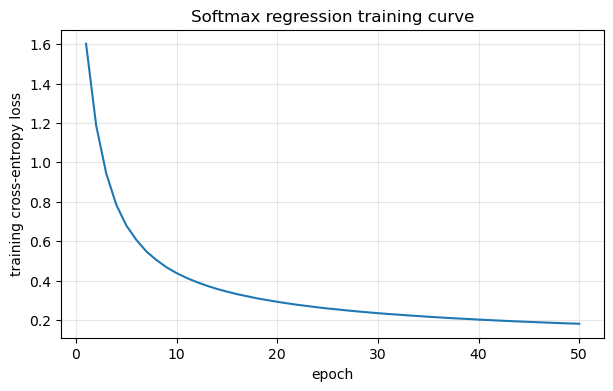

In [8]:
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split

# 1. 加载 digits 数据集
digits = load_digits()
X_raw = digits.data.astype(np.float64) / 16.0
y_raw = digits.target.astype(int)
num_classes = len(np.unique(y_raw))

# 2. one-hot 编码
def one_hot(y, num_classes):
    Y = np.zeros((len(y), num_classes))
    Y[np.arange(len(y)), y] = 1
    return Y

Y_raw = one_hot(y_raw, num_classes)

X_train, X_test, y_train, y_test, Y_train, Y_test = train_test_split(
    X_raw, y_raw, Y_raw, test_size=0.2, random_state=42, stratify=y_raw
)

# 3. softmax 函数
def softmax(logits):
    logits = logits - np.max(logits, axis=1, keepdims=True)
    exp_logits = np.exp(logits)
    return exp_logits / np.sum(exp_logits, axis=1, keepdims=True)

def cross_entropy(probs, Y):
    eps = 1e-12
    return -np.mean(np.sum(Y * np.log(probs + eps), axis=1))

# 4. 训练参数
rng = np.random.default_rng(42)
n_features = X_train.shape[1]
W = rng.normal(0, 0.01, size=(n_features, num_classes))
b = np.zeros(num_classes)

batch_size = 32
lr = 0.1
epochs = 50
loss_history = []

for epoch in range(epochs):
    indices = rng.permutation(len(X_train))
    X_train_shuffled = X_train[indices]
    Y_train_shuffled = Y_train[indices]

    for start in range(0, len(X_train), batch_size):
        end = start + batch_size
        X_batch = X_train_shuffled[start:end]
        Y_batch = Y_train_shuffled[start:end]

        logits = X_batch @ W + b
        probs = softmax(logits)

        grad_logits = (probs - Y_batch) / len(X_batch)
        grad_W = X_batch.T @ grad_logits
        grad_b = np.sum(grad_logits, axis=0)

        W -= lr * grad_W
        b -= lr * grad_b

    train_probs = softmax(X_train @ W + b)
    train_loss = cross_entropy(train_probs, Y_train)
    loss_history.append(train_loss)

# 5. 评估
def accuracy(X, y):
    pred = np.argmax(softmax(X @ W + b), axis=1)
    return np.mean(pred == y)

train_acc = accuracy(X_train, y_train)
test_acc = accuracy(X_test, y_test)

print('Final training loss = {:.4f}'.format(loss_history[-1]))
print('Training accuracy = {:.2f}%'.format(train_acc * 100))
print('Test accuracy = {:.2f}%'.format(test_acc * 100))

plt.figure(figsize=(7, 4))
plt.plot(np.arange(1, epochs + 1), loss_history)
plt.xlabel('epoch')
plt.ylabel('training cross-entropy loss')
plt.title('Softmax regression training curve')
plt.grid(True, alpha=0.3)
plt.show()


以上模型使用纯 NumPy 实现了 softmax 回归。由于 digits 数据集较小，训练 50 个 epoch 后通常可以得到较高的测试准确率。

## 6 极大似然估计与逻辑回归

### 6.1 正态分布参数的极大似然估计

设

$$
x_1,x_2,\ldots,x_n\overset{i.i.d.}{\sim}N(\mu,\sigma^2).
$$

单个样本的密度为

$$
f(x_i\mid\mu,\sigma^2)=\frac{1}{\sqrt{2\pi\sigma^2}}\exp\left[-\frac{(x_i-\mu)^2}{2\sigma^2}\right].
$$

因此联合似然函数为

$$
L(\mu,\sigma^2)=\prod_{i=1}^{n}\frac{1}{\sqrt{2\pi\sigma^2}}\exp\left[-\frac{(x_i-\mu)^2}{2\sigma^2}\right].
$$

对数似然为

$$
\ell(\mu,\sigma^2)=-\frac{n}{2}\log(2\pi)-\frac{n}{2}\log\sigma^2-\frac{1}{2\sigma^2}\sum_{i=1}^{n}(x_i-\mu)^2.
$$

对 $\mu$ 求偏导并令其为 0，可得

$$
\hat{\mu}=\frac{1}{n}\sum_{i=1}^{n}x_i.
$$

将 $\hat\mu$ 代入并对 $\sigma^2$ 求偏导，可得

$$
\hat{\sigma}^{2}=\frac{1}{n}\sum_{i=1}^{n}(x_i-\hat\mu)^2.
$$

注意这里的 MLE 方差估计分母为 $n$，不同于无偏样本方差中的 $n-1$。

In [9]:
# 使用模拟数据验证 MLE 形式
rng = np.random.default_rng(42)
data = rng.normal(loc=2.0, scale=3.0, size=1000)
mu_hat = np.mean(data)
sigma2_hat = np.mean((data - mu_hat) ** 2)

print('mu_hat =', mu_hat)
print('sigma2_hat (MLE) =', sigma2_hat)
print('sample variance with ddof=1 =', np.var(data, ddof=1))


mu_hat = 1.9133253470121594
sigma2_hat (MLE) = 8.798147064547367
sample variance with ddof=1 = 8.806954018565934


### 6.2 使用 sigmoid 实现二分类逻辑回归

根据 PDF 中可识别的关键词与数值，本题要求生成 200 个二分类数据点，使用 sigmoid 函数，设置学习率 0.1，训练 1000 次以估计参数 $w,b$，并输出结果。下面代码使用 NumPy 从零实现逻辑回归。

w = [2.21305368 2.24488923]
b = 0.006610282581620719
final loss = 0.0204
training accuracy = 99.50%

前 100 个样本中预测为 1 的数量 = 43
前 10 个预测概率 = [8.700e-03 8.700e-03 9.999e-01 9.818e-01 1.230e-02 9.531e-01 9.995e-01
 1.290e-02 2.610e-02 1.000e-04]


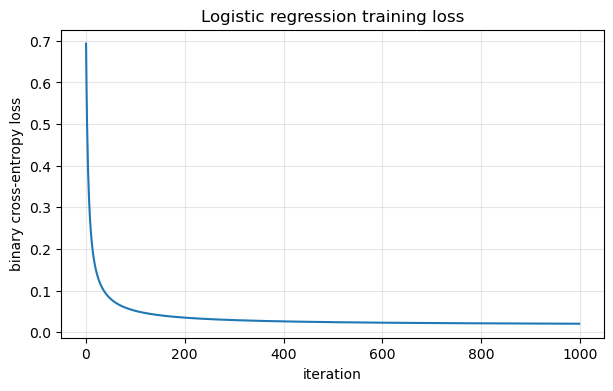

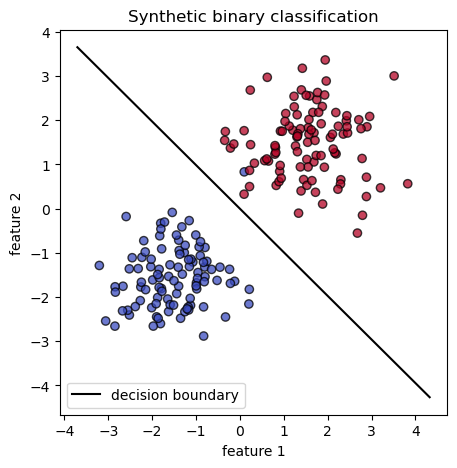

In [10]:
# 1. 生成 200 个二维二分类样本
rng = np.random.default_rng(42)
n_samples = 200
n_half = n_samples // 2

X0 = rng.normal(loc=[-1.5, -1.5], scale=0.8, size=(n_half, 2))
X1 = rng.normal(loc=[1.5, 1.5], scale=0.8, size=(n_half, 2))
X_lr = np.vstack([X0, X1])
y_lr = np.concatenate([np.zeros(n_half), np.ones(n_half)])

# 打乱数据
perm = rng.permutation(n_samples)
X_lr = X_lr[perm]
y_lr = y_lr[perm]

# 2. sigmoid 函数
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# 3. 梯度下降训练
w = np.zeros(X_lr.shape[1])
b_lr = 0.0
lr = 0.1
num_iter = 1000
losses = []

for t in range(num_iter):
    logits = X_lr @ w + b_lr
    probs = sigmoid(logits)

    eps = 1e-12
    loss = -np.mean(y_lr * np.log(probs + eps) + (1 - y_lr) * np.log(1 - probs + eps))
    losses.append(loss)

    grad_w = X_lr.T @ (probs - y_lr) / n_samples
    grad_b = np.mean(probs - y_lr)

    w -= lr * grad_w
    b_lr -= lr * grad_b

# 4. 输出训练结果，并展示前 100 个样本的预测摘要
final_probs = sigmoid(X_lr @ w + b_lr)
preds = (final_probs >= 0.5).astype(int)
acc = np.mean(preds == y_lr)

print('w =', w)
print('b =', b_lr)
print('final loss = {:.4f}'.format(losses[-1]))
print('training accuracy = {:.2f}%'.format(acc * 100))
print('\n前 100 个样本中预测为 1 的数量 =', int(preds[:100].sum()))
print('前 10 个预测概率 =', np.round(final_probs[:10], 4))

plt.figure(figsize=(7, 4))
plt.plot(losses)
plt.xlabel('iteration')
plt.ylabel('binary cross-entropy loss')
plt.title('Logistic regression training loss')
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(5, 5))
plt.scatter(X_lr[:, 0], X_lr[:, 1], c=y_lr, cmap='coolwarm', edgecolor='k', alpha=0.75)
xx = np.linspace(X_lr[:, 0].min() - 0.5, X_lr[:, 0].max() + 0.5, 100)
if abs(w[1]) > 1e-12:
    yy = -(w[0] * xx + b_lr) / w[1]
    plt.plot(xx, yy, color='black', label='decision boundary')
plt.xlabel('feature 1')
plt.ylabel('feature 2')
plt.title('Synthetic binary classification')
plt.legend()
plt.show()


逻辑回归模型学习到的参数 $w,b$ 定义了线性决策边界 $w^Tx+b=0$。在上述合成数据中，两类样本均值相距较远，因此训练准确率通常较高。

## 总结

本 Notebook 已按照 PDF 中的题目结构完成主要计算与推导：第 2 题完成 NumPy 矩阵与范数计算；第 3 题完成贝叶斯概率计算与均匀分布 Monte Carlo 模拟；第 4 题完成手工求导与自动微分；第 5 题完成线性回归梯度推导和 softmax 多分类实现；第 6 题完成正态分布 MLE 推导与 sigmoid 逻辑回归训练。